In [1]:
# Install yfinance
!pip install yfinance

In [2]:
!pip install scikit-learn

In [3]:
!pip install tensorflow

In [4]:
import boto3
import pandas as pd
import numpy as np
import io
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries loaded")

I0000 00:00:1779467397.515205 1458816 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ All libraries loaded


In [5]:
# Load stock data from S3
BUCKET = "stockprediction-datalake-fjose"
TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]
LOOK_BACK = 60

s3 = boto3.client("s3", region_name="eu-west-2")

def load_stock(ticker):
    resp = s3.list_objects_v2(Bucket=BUCKET, Prefix=f"raw/{ticker}/")
    key  = sorted([o["Key"] for o in resp["Contents"]])[-1]
    obj  = s3.get_object(Bucket=BUCKET, Key=key)
    df   = pd.read_csv(io.BytesIO(obj["Body"].read()))
    return df

# Test with AAPL first
df = load_stock("AAPL")
print(df.tail())
print(f"✅ AAPL loaded — {len(df)} rows")

            Date               Close                High                 Low  \
1252  2026-05-11  292.67999267578125   293.8800048828125   290.2300109863281   
1253  2026-05-12  294.79998779296875   295.2699890136719  292.55999755859375   
1254  2026-05-13   298.8699951171875   300.9200134277344               293.5   
1255  2026-05-14   298.2099914550781  300.45001220703125   295.3800048828125   
1256  2026-05-15   300.2300109863281  303.20001220703125   296.5199890136719   

                    Open    Volume  
1252   291.9800109863281  42247300  
1253  292.55999755859375  45748100  
1254               293.5  52684300  
1255  299.82000732421875  35324900  
1256   297.8999938964844  54721100  
✅ AAPL loaded — 1257 rows


In [6]:
def build_sequences(data, look_back):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i-look_back:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

def build_lstm():
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(LOOK_BACK, 1)),
        Dropout(0.2),
        LSTM(64),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

print("✅ Functions ready")

✅ Functions ready


In [ ]:
results = {}

for ticker in TICKERS:
    print(f"\n=== Training {ticker} ===")
    df = load_stock(ticker)
    prices = pd.to_numeric(df["Close"], errors='coerce').dropna().values.reshape(-1, 1)

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(prices)

    split = int(len(scaled) * 0.8)
    X_tr, y_tr = build_sequences(scaled[:split], LOOK_BACK)
    X_te, y_te = build_sequences(scaled[split:], LOOK_BACK)

    X_tr = X_tr.reshape(-1, LOOK_BACK, 1)
    X_te = X_te.reshape(-1, LOOK_BACK, 1)

    model = build_lstm()
    model.fit(X_tr, y_tr, epochs=20, batch_size=32,
              validation_split=0.1, verbose=1)

    # Predict next year and a half
    last_seq = scaled[-LOOK_BACK:].reshape(1, LOOK_BACK, 1)
    future_preds = []
    for _ in range(547):
        pred = model.predict(last_seq, verbose=0)[0, 0]
        future_preds.append(pred)
        last_seq = np.roll(last_seq, -1)
        last_seq[0, -1, 0] = pred

    future_prices = scaler.inverse_transform(
        np.array(future_preds).reshape(-1, 1)
    )

    results[ticker] = future_prices.flatten()

    # Save predictions to S3
    pred_df = pd.DataFrame({
        "day": range(1, 548),
        "predicted_close": future_prices.flatten()
    })
    buf = io.StringIO()
    pred_df.to_csv(buf, index=False)
    s3.put_object(
        Bucket=BUCKET,
        Key=f"predictions/{ticker}_547day.csv",
        Body=buf.getvalue()
    )
    print(f"✅ {ticker} predictions saved to S3")

print("\n🎉 All 5 stocks trained and predictions saved!")


=== Training AAPL ===
Epoch 1/20


E0000 00:00:1779467886.017765 1458816 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.0137 - val_loss: 0.0050
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0026 - val_loss: 0.0045
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0023 - val_loss: 0.0072
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0021 - val_loss: 0.0060
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0021 - val_loss: 0.0039
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0020 - val_loss: 0.0038
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0018 - val_loss: 0.0058
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0020 - val_loss: 0.0036
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0017 - val_loss: 0.0054
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0016 - val_loss: 0.0054
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0016 - val_loss: 0.0037
Epoch 12/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0016 - val_l

In [10]:
!pip install matplotlib

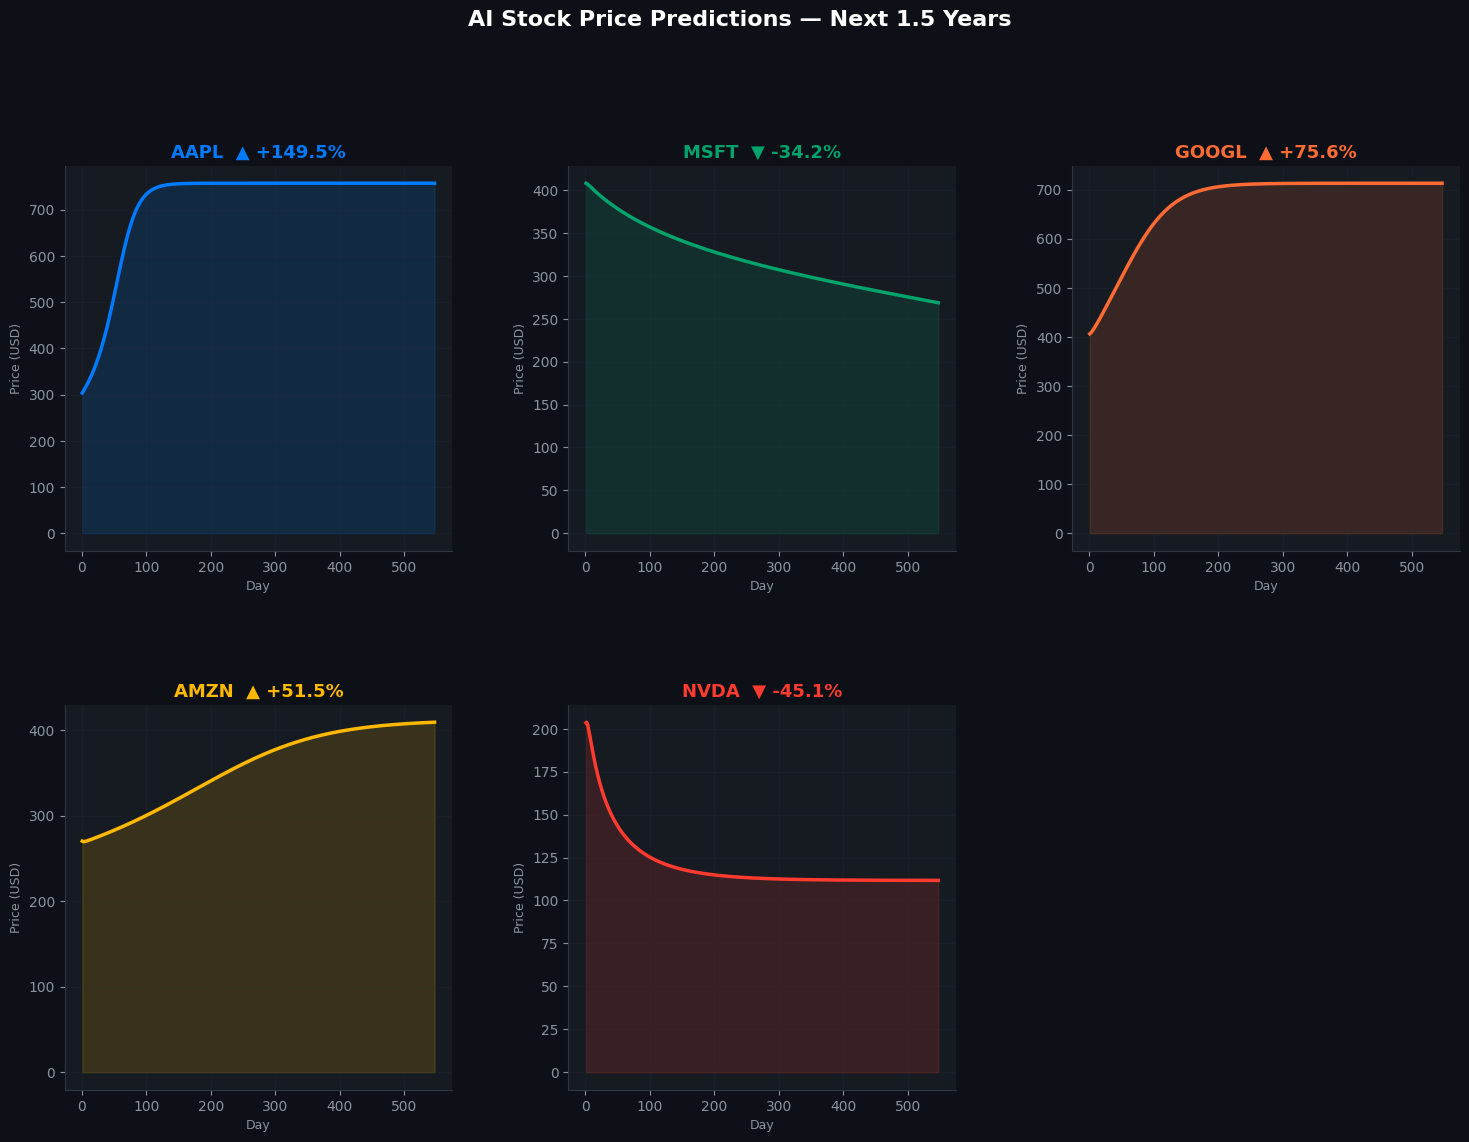

✅ Dashboard saved!


In [11]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

colors = {
    "AAPL": "#007AFF",
    "MSFT": "#00A36C", 
    "GOOGL": "#FF6B35",
    "AMZN": "#FFB800",
    "NVDA": "#FF3B30"
}

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#0D1117')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.3)

axes = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1]),
        fig.add_subplot(gs[0,2]), fig.add_subplot(gs[1,0]),
        fig.add_subplot(gs[1,1])]

for idx, ticker in enumerate(TICKERS):
    obj = s3.get_object(Bucket=BUCKET, Key=f"predictions/{ticker}_547day.csv")
    pred_df = pd.read_csv(io.BytesIO(obj["Body"].read()))
    
    ax = axes[idx]
    ax.set_facecolor('#161B22')
    color = colors[ticker]
    
    ax.plot(pred_df["day"], pred_df["predicted_close"], 
            color=color, linewidth=2.5)
    ax.fill_between(pred_df["day"], pred_df["predicted_close"], 
                    alpha=0.15, color=color)
    
    start = pred_df["predicted_close"].iloc[0]
    end   = pred_df["predicted_close"].iloc[-1]
    pct   = ((end - start) / start) * 100
    arrow = "▲" if pct > 0 else "▼"
    
    ax.set_title(f"{ticker}  {arrow} {pct:+.1f}%", 
                 color=color, fontsize=13, fontweight='bold')
    ax.set_xlabel("Day", color='#8B949E', fontsize=9)
    ax.set_ylabel("Price (USD)", color='#8B949E', fontsize=9)
    ax.tick_params(colors='#8B949E')
    ax.spines[['top','right']].set_visible(False)
    for spine in ['bottom','left']:
        ax.spines[spine].set_color('#30363D')
    ax.grid(True, alpha=0.15, color='#30363D')

fig.suptitle("AI Stock Price Predictions — Next 1.5 Years", 
             color='white', fontsize=16, fontweight='bold', y=1.01)

plt.savefig("stock_predictions_547.png", dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()
print("✅ Dashboard saved!")